# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 4</span>
### <span style= "color: black" > Es04.1

In questo esercizio viene aggiunto il calcolo della pressione $P$ al codice `system.cpp`. In particolare, tenendo conto del teorema del Viriale, l'espressione per il calcolo di $P$ è (in unità ridotte):

$$ P = \rho T + \frac{1}{3V} \left\langle \sum_{i=1}^{N-1} \sum_{j\,(>i)}^N 48 \left[ \left(\frac{1}{|\vec{r}_i -\vec{r}_j|}\right)^{12} - 
\frac{1}{2} \left(\frac{1}{|\vec{r}_i -\vec{r}_j|}\right)^6 \right] \right\rangle $$

In particolare la pressione media ed il suo errore statistico vengono calcolate secondo il metodo del data blocking. 

### <span style= "color: black" > Es04.2

Lo scopo di questo esercizio è eseguire simulazioni di dinamica molecolare di un sistema di 108 particelle di Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) utilizzando un modello di Lennard-Jones, nelle seguenti condizioni:
1. fase solida: $\rho^\star = 1.1$, $T^\star = 0.8$ (raggio di cut-off: $r_c = 2.2$)
2. fase liquida: $\rho^\star = 0.8$, $T^\star = 1.1$ (raggio di cut-off: $r_c = 2.5$)
3. fase gassosa: $\rho^\star = 0.05$, $T^\star = 1.2$ (raggio di cut-off: $r_c = 5.0$)

In particolare si vuole calcolare l'energia totale (interna) per particella, $E/N$, l'energia potenziale per particella, $U/N$, l'energia cinetica per particella, $K/N$, la temperatura, $T$, e la pressione, $P$, in unità ridotte. L'uso delle unità ridotte permette di generalizzare l'analisi, rendendola applicabile anche oltre il caso specifico dell'Argon (infatti non verranno utilizzati direttamente i valori specifici $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu). Per stimare queste grandezze e le relative incertezze statistiche, viene utilizzato il metodo del data blocking, suddividendo le misure statistiche in $N = 20$ blocchi da $L = 2000$ step (*throws*) ciascuno.


Il primo step della simulazione è l'equilibrazione del sistema. Questo passaggio è necessario perché, in una simulazione di dinamica molecolare microcanonica (le grandezze termodinamiche fissate sono infatti: $N$, numero di particelle fissato a $108$, $V$, volume della scatola in cui le particelle sono confinate ed il cui lato in unità ridotte è $L^\star = \left(\frac{N}{\rho^\star}\right)^{1/3}$, ed $E_{tot}$, poiché il sistema non scambia energia con l'esterno), la temperatura non è fissata direttamente durante l'evoluzione: essa dipende dall'energia cinetica media del sistema.

Nel caso in cui la simulazione venga avviata con `RESTART = 0`, le velocità iniziali non vengono lette da una configurazione precedente, ma vengono generate dal programma e successivamente riscalate in modo che la temperatura cinetica iniziale corrisponda al valore impostato nel file di input. Tale valore, quindi, fissa solo la scala iniziale delle velocità, ma non impone la temperatura durante tutta l'evoluzione.

Di conseguenza, impostare come temperatura iniziale il valore desiderato $T^\star$ non garantisce che, dopo il transiente iniziale, il sistema si stabilizzi proprio attorno a quel valore. Durante l'equilibrazione, infatti, l'energia viene redistribuita tra energia cinetica ed energia potenziale; poiché l'energia totale è conservata, una variazione dell'energia potenziale comporta una variazione dell'energia cinetica e quindi della temperatura.

Per questo motivo, per ciascuna fase sono stati esplorati diversi valori della temperatura iniziale $T$ ed è stato scelto quello che, dopo un certo numero di step di equilibrazione, porta la temperatura media del sistema ad oscillare attorno al valore desiderato $T^\star$.

In particolare, i valori di temperatura iniziale scelti per ottenere, dopo l'equilibrazione, le temperature target $T^\star$ sono:
1. fase solida: $T = 1.55$
2. fase liquida: $T = 1.99$
3. fase gassosa: $T = 0.97$

Per monitorare il processo di equilibrazione, viene seguita l’evoluzione della temperatura in funzione degli step di simulazione, considerando la media della temperatura calcolata all’interno di ciascun blocco e non la media progressiva sull’intera simulazione.
Questo approccio è più utile rispetto all’uso di una media progressiva in questa fase, poiché una media progressiva manterrebbe il contributo dei valori iniziali non equilibrati e renderebbe più difficile individuare quando il sistema ha effettivamente raggiunto un regime stazionario.

Il monitoraggio dell’equilibrazione è stato effettuato per tutte le grandezze fisiche considerate. Tuttavia, in questa sezione vengono riportati solo gli andamenti della temperatura in funzione del numero di step, poiché la scelta del tempo di equilibrazione e della temperatura iniziale è basata principalmente su questa osservabile.

Di seguito si mostra quanto ottenuto per la fase solida utilizzando $500$ blocchi da $10$ steps ciascuno:

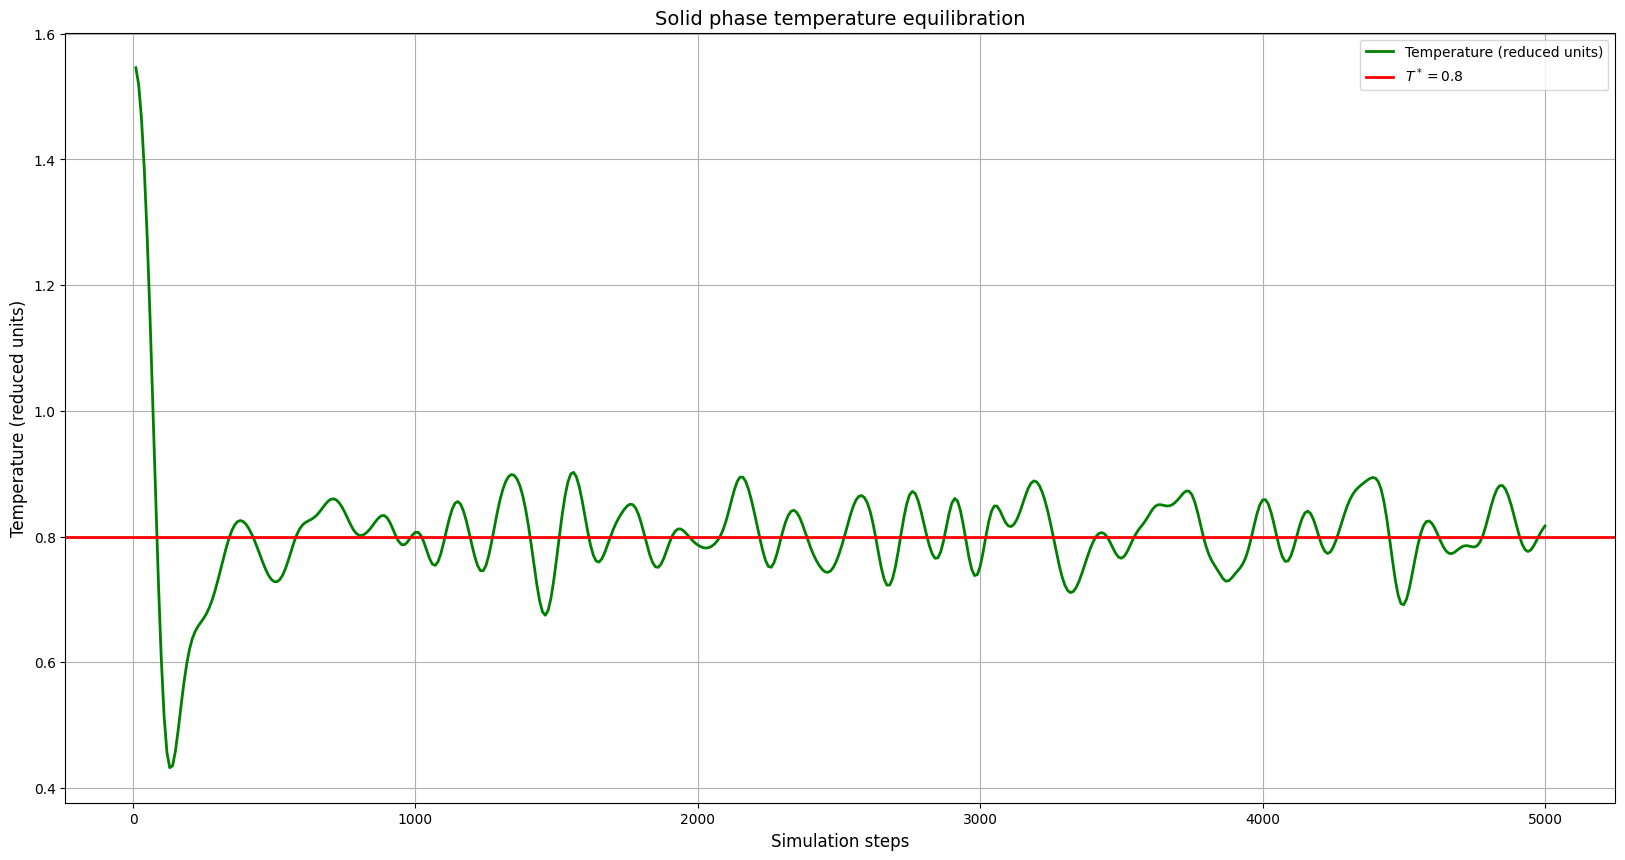

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot(filename, y_name, color, n, target_T=None, steps_per_block=1, title=None, x_name=None, ax=None, legend = False):
    data = np.loadtxt(filename, skiprows=1)

    block = data[:, 0]
    steps = block * steps_per_block
    y = data[:, n]
    error = data[:, 3]

    if title is None:
        title = y_name

    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 10))
        single_plot = True
    else:
        single_plot = False

    if n == 1:
        x = steps
        if x_name is None:
            x_name = "Simulation steps"
        ax.plot(x, y, color=color, linewidth=2, label=y_name)

    elif n == 2:
        x = block
        if x_name is None:
            x_name = "Number of blocks"
        ax.errorbar(x, y, yerr=error, fmt="o-", color=color, markersize=5, label=y_name)

    if target_T is not None:
        ax.axhline(target_T, linestyle="-", linewidth=2, color="red", label=rf"$T^* = {target_T}$")

    ax.set_xlabel(x_name, fontsize=12)
    ax.set_ylabel(y_name, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True)
    if legend is not False:
        ax.legend(fontsize=10)

    if single_plot:
        plt.show()
    
plot("NSL_SIMULATOR/OUTPUT/temperature_solid_equilibration.dat", "Temperature (reduced units)", "green", 1, target_T=0.8, steps_per_block=10, title="Solid phase temperature equilibration", legend = True)


Si riportano ora i risultati ottenuti per la fase liquida ottenuti considerando $1500$ blocchi da $10$ steps ciascuno:

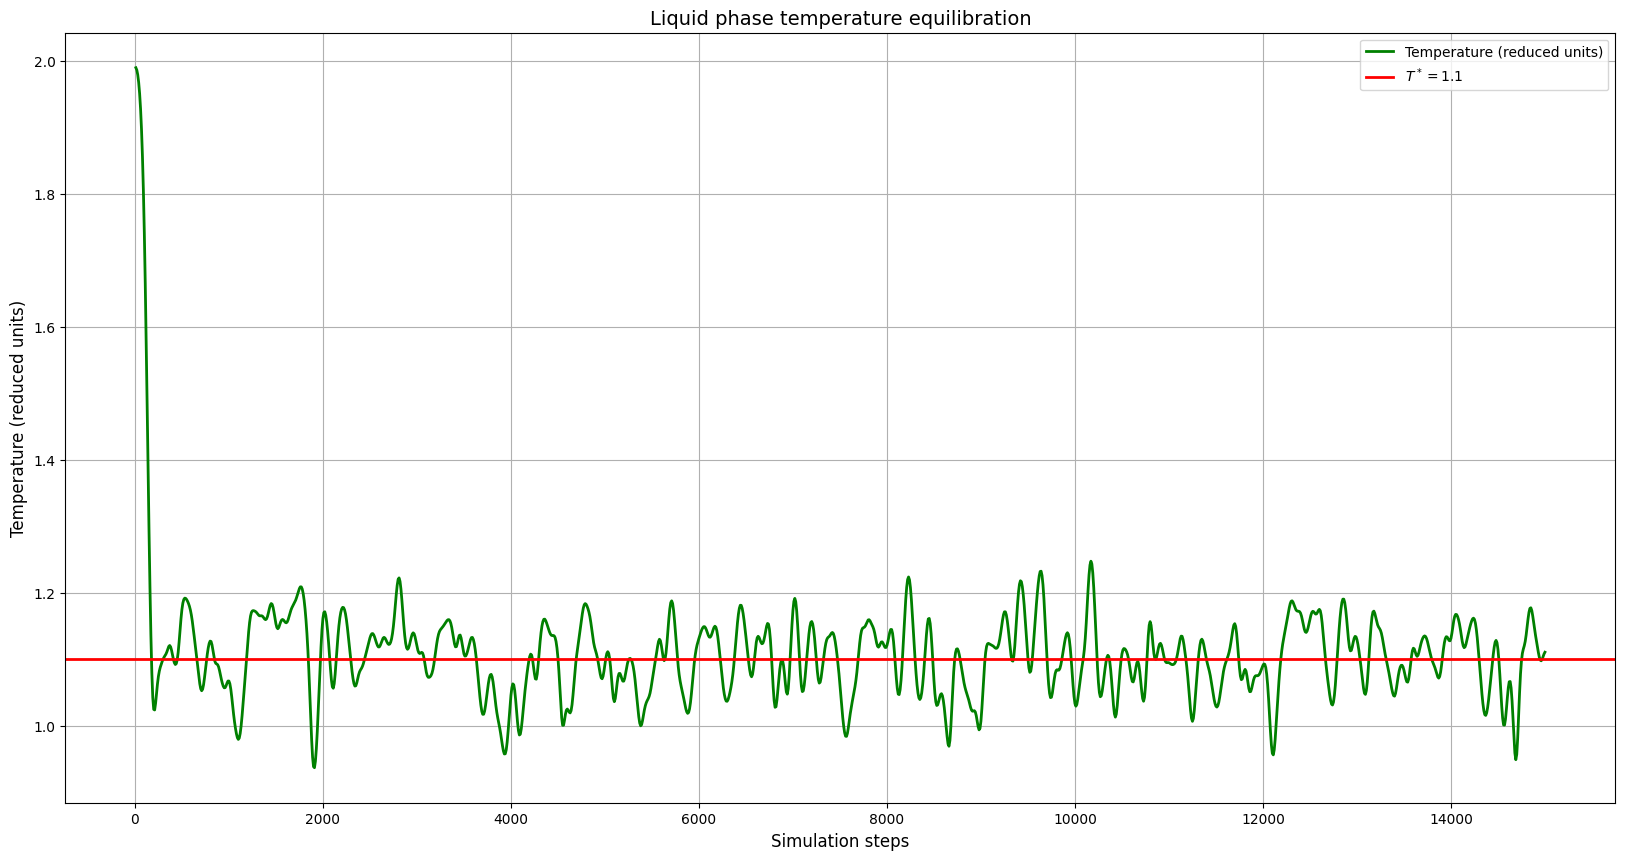

In [11]:
plot("NSL_SIMULATOR/OUTPUT/temperature_liquid_equilibration.dat", "Temperature (reduced units)", "green", 1, target_T=1.1, steps_per_block=10, title="Liquid phase temperature equilibration", legend=True)

Osservando questi grafici si nota chiaramente un transiente iniziale, seguito da oscillazioni attorno a un valore medio ben definito. Questo indica che il sistema ha raggiunto un regime stazionario.

Nel caso solido la temperatura presenta oscillazioni meno ampie rispetto al caso liquido. Questo è coerente con il fatto che, nella fase liquida, il sistema è meno ordinato e le particelle hanno una maggiore mobilità, con conseguenti fluttuazioni più marcate della temperatura.

In entrambi i casi, dopo l’equilibrazione, la temperatura oscilla attorno al valore desiderato: $T^\star = 0.8$ per la fase solida e $T^\star = 1.1$ per la fase liquida.

Infine, si riportano i risultati ottenuti per la fase gassosa:

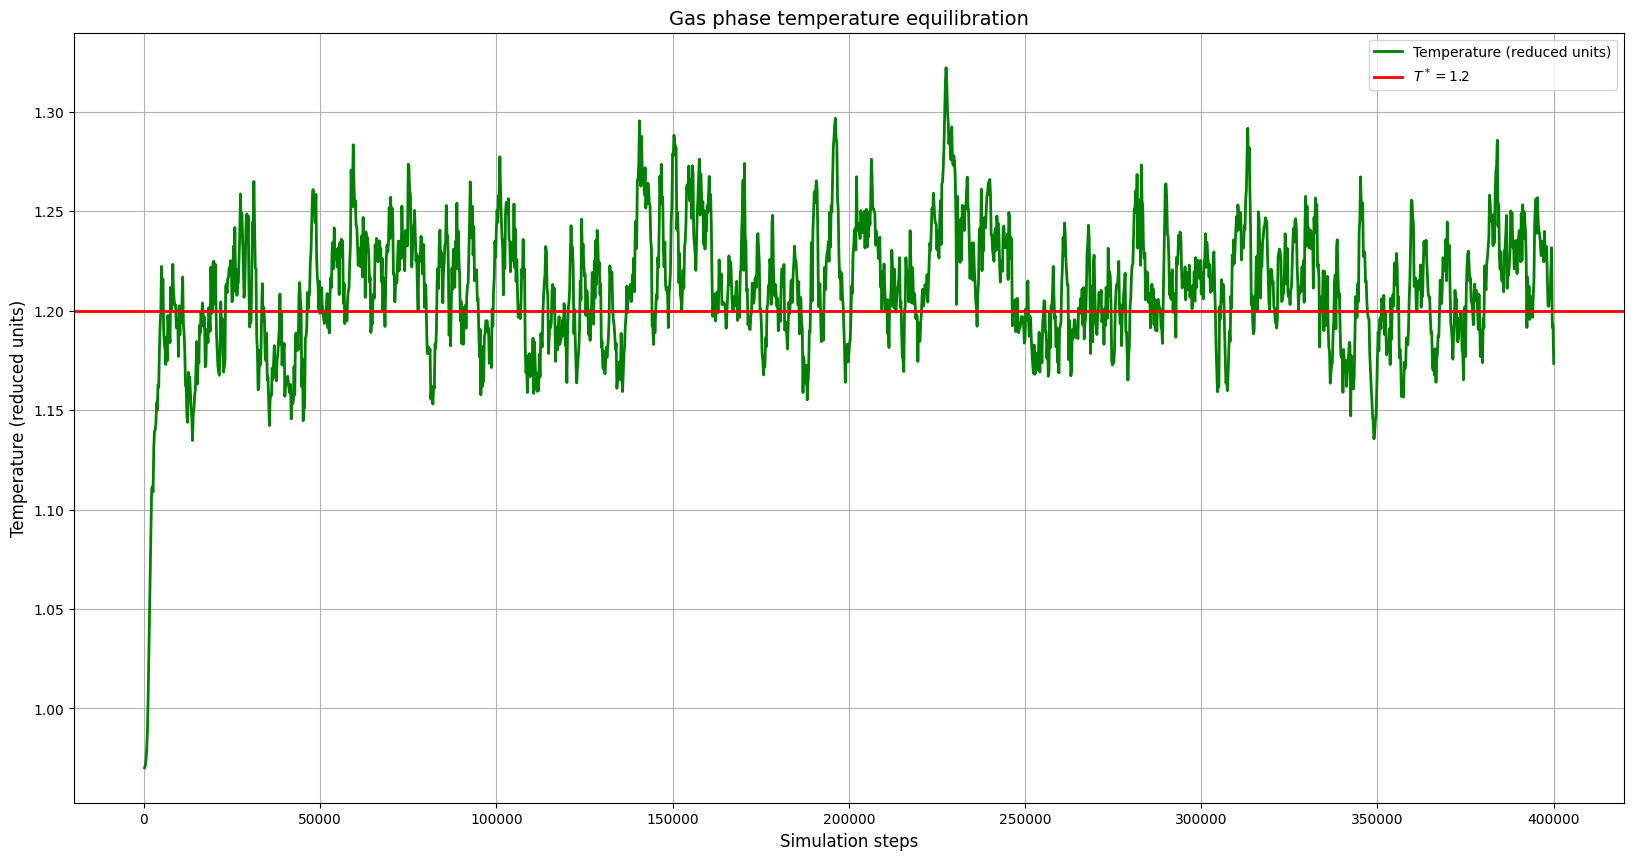

In [12]:
plot("NSL_SIMULATOR/OUTPUT/temperature_gas_equilibration.dat", "Temperature (reduced units)", "green", 1, target_T=1.2, steps_per_block=200, title="Gas phase temperature equilibration", legend=True)

Come atteso, il comportamento della fase gassosa è piuttosto diverso rispetto ai casi solido e liquido. A causa della densità molto più bassa, le interazioni tra particelle sono meno frequenti e la temperatura presenta fluttuazioni più ampie. Per questo motivo è stata effettuata una simulazione di equilibrazione più lunga, utilizzando $2000$ blocchi da $200$ step ciascuno.

Sebbene la temperatura presenti oscillazioni molto più marcate rispetto alla fase solida e liquida, dopo il transiente iniziale il sistema oscilla attorno al valore target $T^\star = 1.2$. La fase gassosa può quindi essere considerata equilibrata dopo un tempo di equilibrazione più lungo rispetto alle fasi solida e liquida.

A questo punto, una volta terminata l'equilibrazione, viene eseguita la simulazione di con `RESTART = 1`, impostando nel file di input le temperature target $T^\star$ delle diverse fasi.
Con `RESTART = 1` la simulazione non viene inizializzata da una nuova configurazione fcc con velocità generate casualmente, ma riparte dalla configurazione salvata al termine dell'equilibrazione. In particolare, vengono riutilizzate le posizioni e le velocità finali della run precedente. In questo modo il sistema parte già da uno stato equilibrato e le grandezze fisiche possono essere misurate senza includere il transiente iniziale nelle medie statistiche.
Vengono riportate le grandezze fisiche con le rispettive barre di errore in funzione del numero di blocchi.

Qui sotto vengono riportati i risultati ottenuti per la fase solida per la quale sono stati considerati $50$ blocchi da $2000$ steps ciascuno:

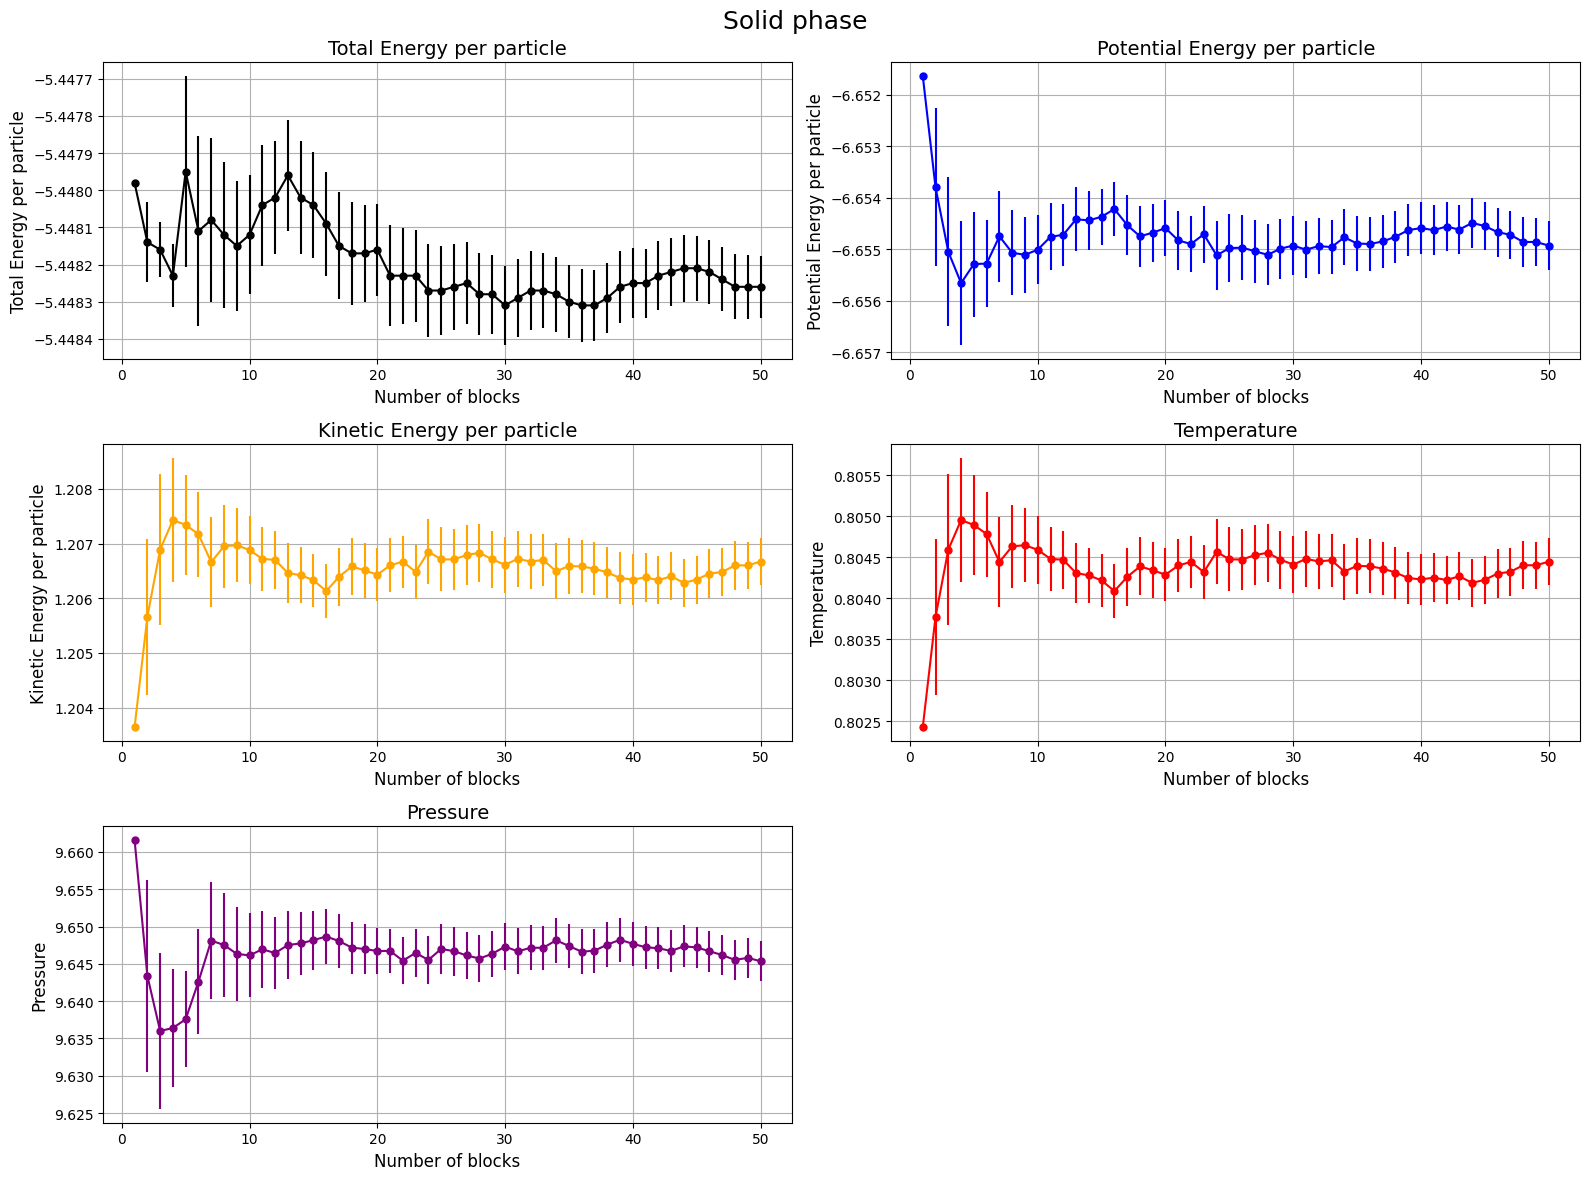

In [13]:

fig, axs = plt.subplots(3, 2, figsize=(16, 12))
axs = axs.flatten()

plot("NSL_SIMULATOR/OUTPUT/Solid_Eq/total_energy.dat", "Total Energy per particle", "black", 2, ax=axs[0])
plot("NSL_SIMULATOR/OUTPUT/Solid_Eq/potential_energy.dat","Potential Energy per particle", "blue", 2, ax=axs[1])
plot("NSL_SIMULATOR/OUTPUT/Solid_Eq/kinetic_energy.dat","Kinetic Energy per particle", "orange", 2, ax=axs[2])
plot("NSL_SIMULATOR/OUTPUT/Solid_Eq/temperature.dat","Temperature", "red", 2, ax=axs[3])
plot("NSL_SIMULATOR/OUTPUT/Solid_Eq/pressure.dat","Pressure", "purple", 2, ax=axs[4])

fig.delaxes(axs[5])
fig.suptitle("Solid phase", fontsize=18)
plt.tight_layout()
plt.show()

Si riportano ora i risultati ottenuti per la fase liquida per la quale sono stati considerati $50$ blocchi da $2000$ steps ciascuno:

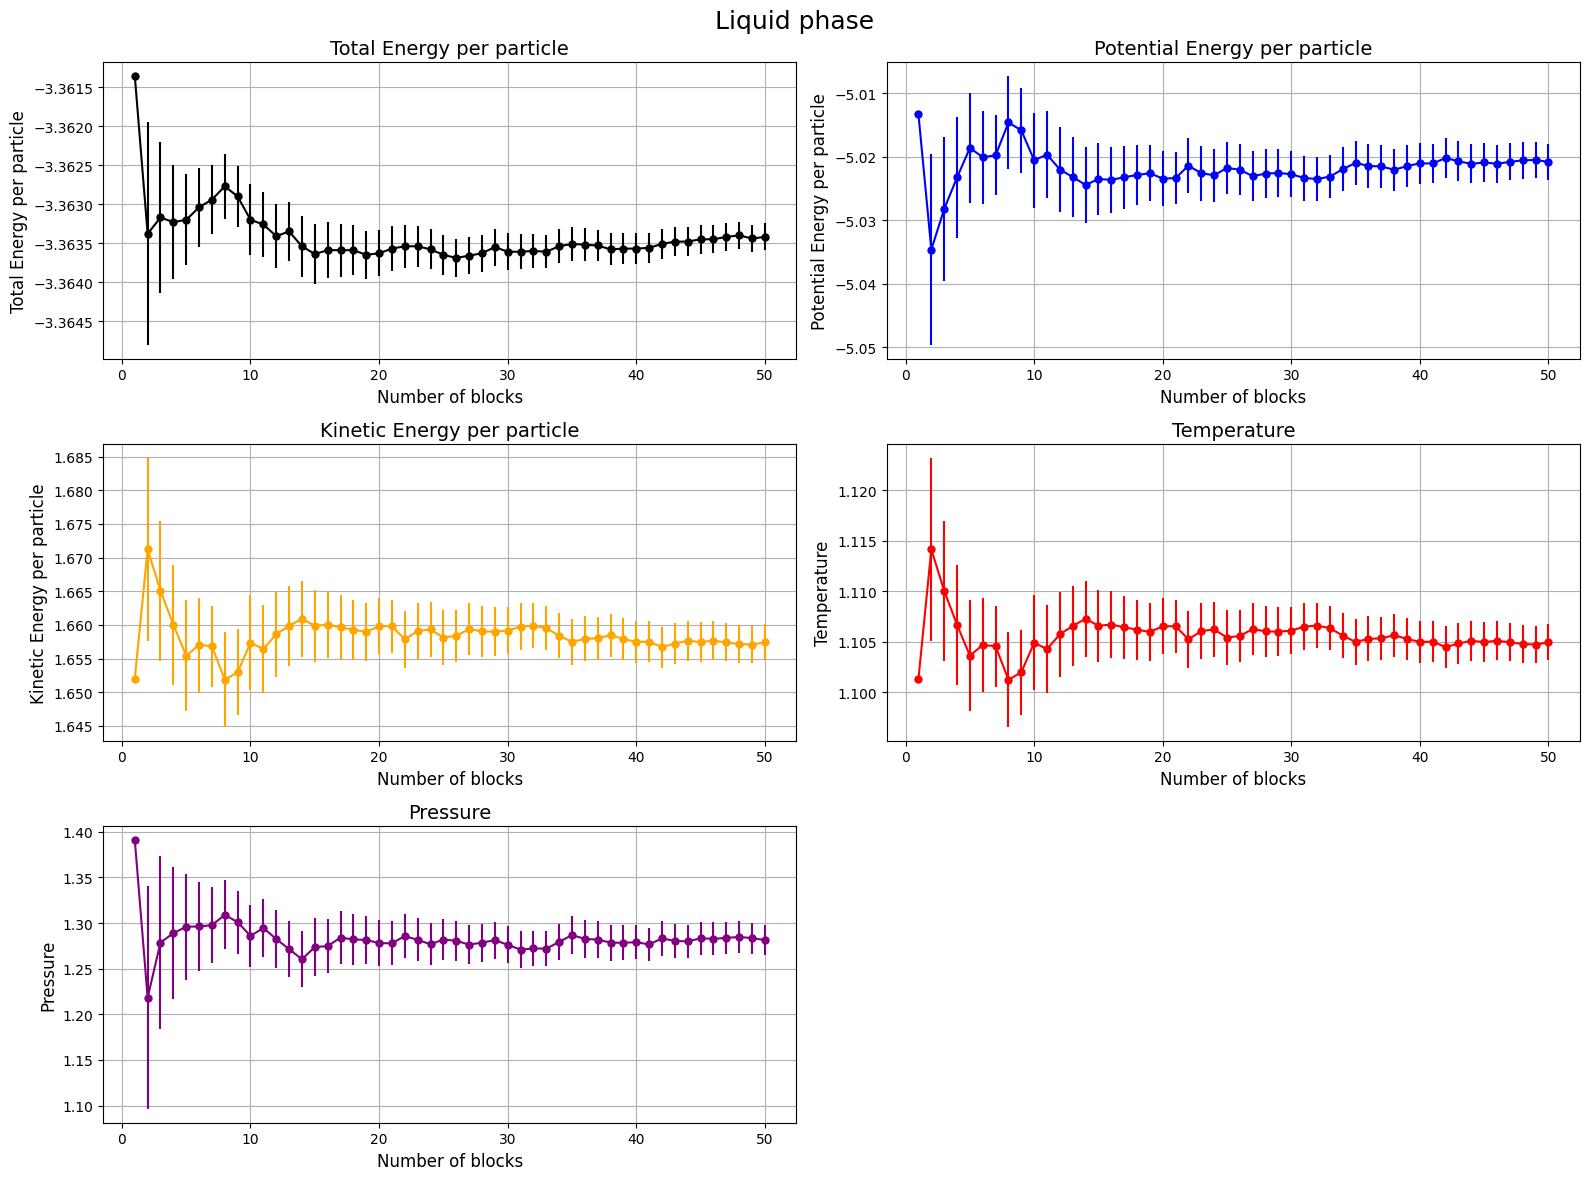

In [8]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
axs = axs.flatten()

plot("NSL_SIMULATOR/OUTPUT/Liquid_Eq/total_energy.dat", "Total Energy per particle", "black", 2, ax=axs[0] )
plot("NSL_SIMULATOR/OUTPUT/Liquid_Eq/potential_energy.dat", "Potential Energy per particle", "blue", 2, ax=axs[1])
plot("NSL_SIMULATOR/OUTPUT/Liquid_Eq/kinetic_energy.dat", "Kinetic Energy per particle", "orange", 2, ax=axs[2])
plot("NSL_SIMULATOR/OUTPUT/Liquid_Eq/temperature.dat", "Temperature", "red", 2, ax=axs[3])
plot("NSL_SIMULATOR/OUTPUT/Liquid_Eq/pressure.dat", "Pressure", "purple", 2, ax=axs[4])

fig.delaxes(axs[5])
fig.suptitle("Liquid phase", fontsize=18)
plt.tight_layout()
plt.show()

Infine vengono esposti i risultati ottenuti anche per la fase gassosa. Anche in questo caso le misure statistiche sono state divise in $50$ blocchi da $2000$ steps ciascuno:

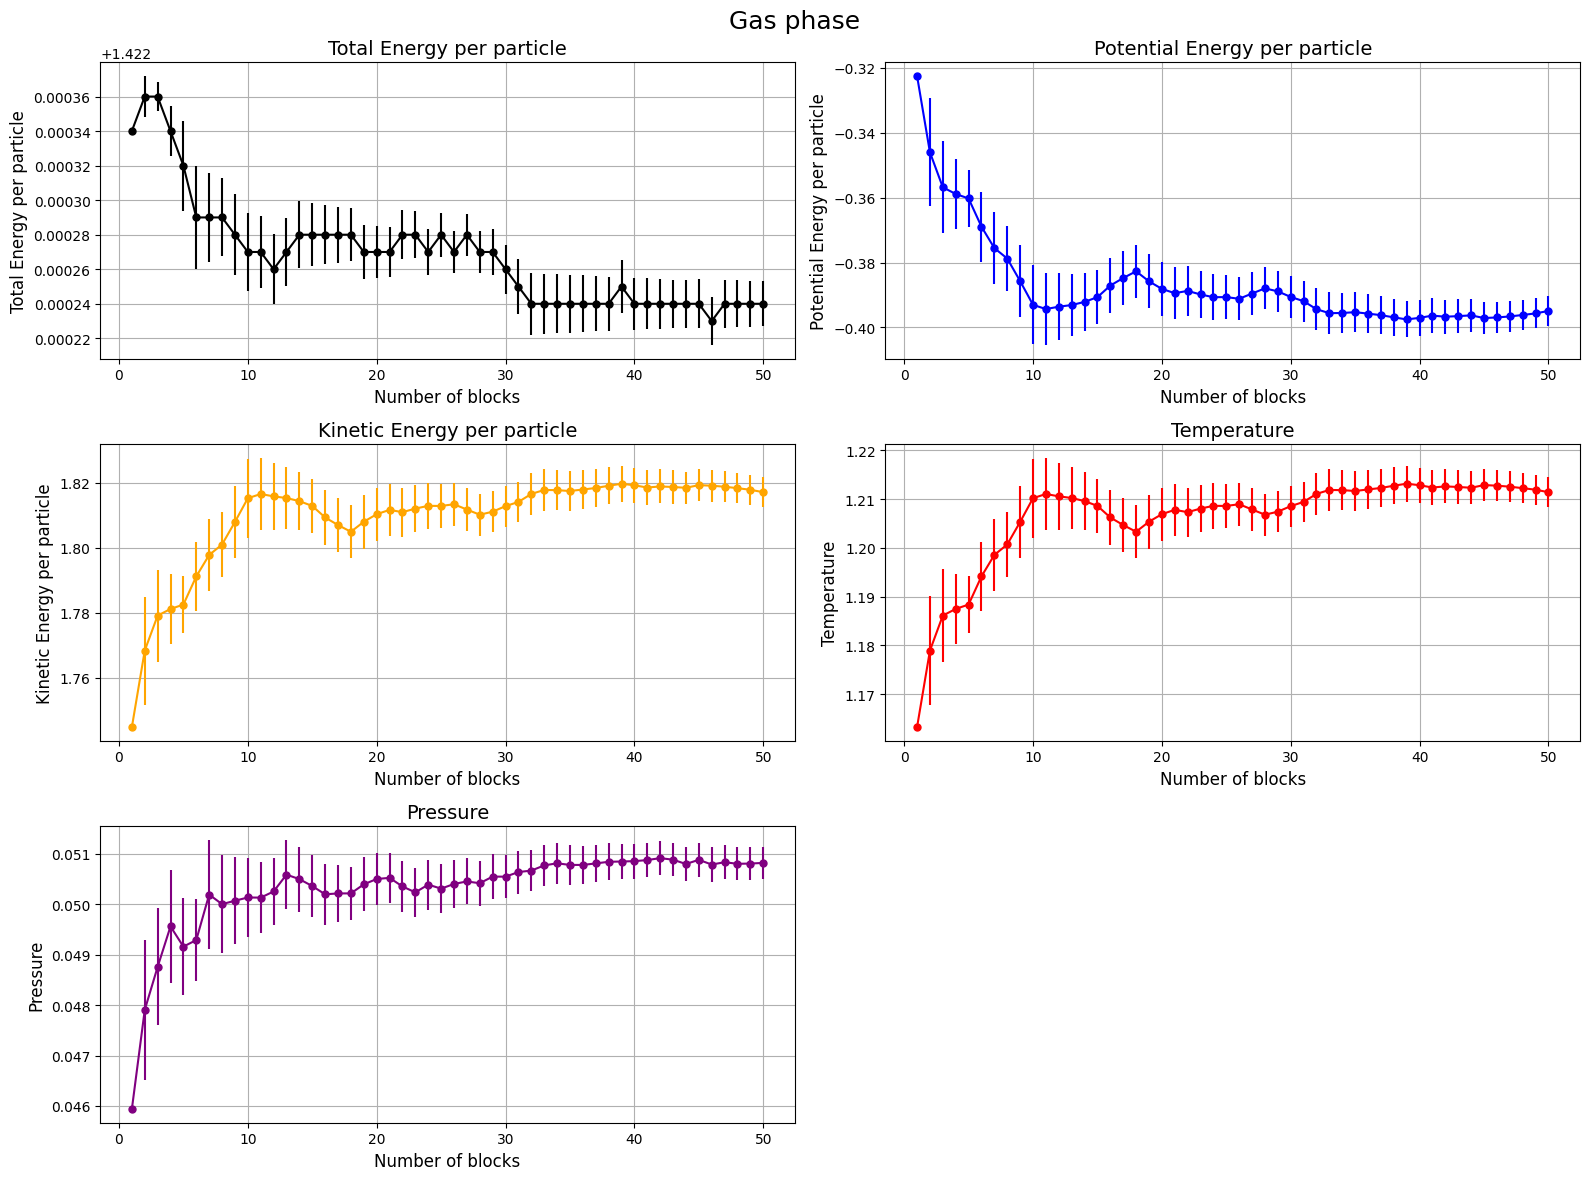

In [6]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
axs = axs.flatten()

plot("NSL_SIMULATOR/OUTPUT/Gas_Eq/total_energy.dat", "Total Energy per particle", "black", 2, ax=axs[0])
plot("NSL_SIMULATOR/OUTPUT/Gas_Eq/potential_energy.dat", "Potential Energy per particle", "blue", 2, ax=axs[1])
plot("NSL_SIMULATOR/OUTPUT/Gas_Eq/kinetic_energy.dat", "Kinetic Energy per particle", "orange", 2, ax=axs[2])
plot("NSL_SIMULATOR/OUTPUT/Gas_Eq/temperature.dat", "Temperature", "red", 2, ax=axs[3])
plot("NSL_SIMULATOR/OUTPUT/Gas_Eq/pressure.dat", "Pressure", "purple", 2, ax=axs[4])

fig.delaxes(axs[5])
fig.suptitle("Gas phase", fontsize=18)
plt.tight_layout()
plt.show()

In tutti e tre i casi dai grafici si osserva che le medie progressive delle grandezze considerate tendono a stabilizzarsi all’aumentare del numero di blocchi e che l'errore diminuisce all'aumentare del numero dei blocchi.